In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
# Load preprocessed dataset
df = pd.read_csv("secondary_data_preprocessed.csv")

In [21]:
X = df.drop(columns=["class_encoded"], errors="ignore")
y = df["class_encoded"]

In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Model & Parameter Tuning
log_reg = LogisticRegression(max_iter=500, solver='lbfgs')
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2']}
grid_lr = GridSearchCV(log_reg, param_grid, cv=5)
grid_lr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=500),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2']})

In [25]:
best_lr = grid_lr.best_estimator_
print("Best Parameters:", grid_lr.best_params_)

Best Parameters: {'C': 0.1, 'penalty': 'l2'}


In [27]:
# Evaluation 
y_pred = best_lr.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6934137291280148
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.58      0.63      4850
           1       0.70      0.78      0.74      5930

    accuracy                           0.69     10780
   macro avg       0.69      0.68      0.68     10780
weighted avg       0.69      0.69      0.69     10780



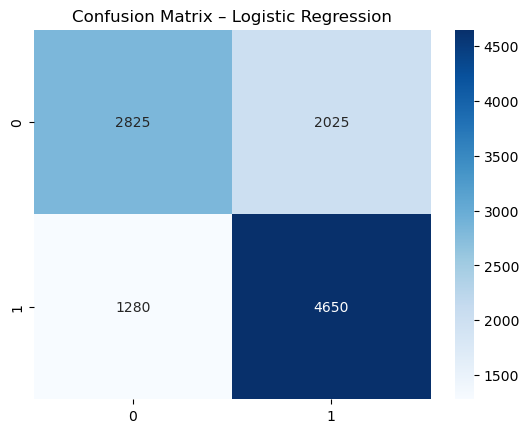

In [29]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()